# Oster phase-template clustering on fetal MCG (P089)

`fmcg.analysis.phase_template.build_phase_template` warps every beat onto a common cardiac-phase
grid, clusters beats by QRS cross-correlation, and averages the largest cluster into a clean
template. `select_secondary_cluster` then pulls out a distinct secondary mode (here the ectopic
beats). This notebook shows the call, visualises the clusters it finds, and checks the templates
against plain averaging on a recording with ectopic beats.

Reconstruction, classification, segment and settings follow
`notebooks/untrained_models_for_dynamics/p089_ectopic_vcg.ipynb`.

In [1]:
import os, sys, logging
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib.gridspec import GridSpec

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from fmcg.pipeline.preprocessing import load_and_preprocess
from fmcg.fitting.field_model import ForwardModel
from fmcg.analysis.hr import compute_hr
from fmcg.analysis.heartbeat_averaging import extract_epochs
from fmcg.ica.ica import apply_ICA
from fmcg.ica.ics import ics
from fmcg.analysis.phase_template import build_phase_template, select_secondary_cluster

logging.basicConfig(level=logging.ERROR, format='%(message)s', force=True)
DS_PATH = '/jonas/fMCG/cache/datasets/fMCG'
CACHE = '/jonas/fMCG/cache'
QRS_HALFWIDTH_MS = 80    # QRS correlation window (matches p089 +-0.08 s)
N_PER_CLASS = 5          # beats averaged per class in the comparison below

In [2]:
def reconstruct_fetal_ics(patient, series, sig_group, noise_group, t0, t1, ds=2,
                          n_components=10, fetal_band=(120, 175)):
    """ICA + ICS fetal reconstruction; fetal components picked by heart rate."""
    cache = os.path.join(CACHE, f'oster_ics_{patient}_{series}_{sig_group}_{t0}-{t1}.npz')
    if os.path.exists(cache):
        z = np.load(cache, allow_pickle=True)
        return (z['field_fetal'], np.asarray(z['peaks']), int(z['fs']),
                z['r_sensors'], np.asarray(z['axis_mask']) == 1, np.asarray(z['W_n']))
    fm, _, axis_mask, W_n, fs, time, r_sensors, _, _ = load_and_preprocess(
        ds_path=DS_PATH, patient=patient, series=series, sig_group_names=sig_group,
        noise_group_names=noise_group, whitening='PCA', downsample_factor=ds)
    fs = int(fs)
    X = fm[(time >= t0) & (time <= t1)][:, axis_mask]
    S, ica = apply_ICA(X, n_comp=n_components)
    bpm = []
    for i in range(S.shape[1]):
        try:
            _, pk = compute_hr(S[:, i], fs, plot=False, fetal=True)
            bpm.append(60 * fs / np.median(np.diff(pk)) if len(pk) > 2 else np.nan)
        except Exception:
            bpm.append(np.nan)
    bpm = np.array(bpm)
    fetals = np.where((bpm >= fetal_band[0]) & (bpm <= fetal_band[1]))[0]
    field_fetal, _ = ics(ica, X, S, list(fetals), fs, keep_sources=True, field_subtract=False)
    _, peaks = compute_hr(np.linalg.norm(field_fetal, axis=1), fs, plot=False, fetal=True)
    peaks = np.asarray(peaks)
    np.savez(cache, field_fetal=field_fetal, peaks=peaks, fs=fs, r_sensors=r_sensors,
             axis_mask=axis_mask, W_n=W_n, fetals=fetals)
    print(f'{patient} fetal comps {fetals} ({np.round(bpm[fetals]).astype(int)} bpm), '
          f'{len(peaks)} beats @ {60*fs/np.median(np.diff(peaks)):.0f} bpm')
    return field_fetal, peaks, fs, r_sensors, np.asarray(axis_mask) == 1, np.asarray(W_n)


def plot_clusters(B, ec_idx=None):
    """Overlay the phase-warped beats, coloured by cluster membership."""
    ph, sl = B['phase_axis'], B['qrs_slice']
    mag = np.linalg.norm(B['beats'], axis=2)
    members = set(B['member_idx'].tolist())
    ect = set(ec_idx.tolist()) if ec_idx is not None else set()
    fig, ax = plt.subplots(figsize=(8, 3.6), dpi=120)
    ax.axvspan(ph[sl][0], ph[sl][-1], color='y', alpha=0.1)
    for i in range(len(mag)):
        c, a = ('C0', 0.25) if i in members else (('m', 0.6) if i in ect else ('0.75', 0.4))
        ax.plot(ph, mag[i], color=c, lw=0.5, alpha=a)
    ax.plot(ph, np.linalg.norm(B['mean'], axis=1), 'k', lw=2)
    ax.plot([], [], 'C0', label=f'normal cluster (n={B["n_members"]})')
    if ec_idx is not None:
        ax.plot([], [], 'm', label=f'ectopic cluster (n={len(ec_idx)})')
    ax.plot([], [], '0.75', label='rejected')
    ax.plot([], [], 'k', lw=2, label='template')
    ax.set(xlabel='cardiac phase [rad]', ylabel='|beat|',
           title='phase-warped beats coloured by cluster (QRS window shaded)')
    ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()


def make_vcg_projector(field_template, r_sensors, valid, W_n):
    """Fit a dipole position to a field template; return a field(C) -> VCG(3) projector."""
    FM = ForwardModel(r_sensors); Wnp = np.asarray(W_n)

    def lead(r):
        r_t = np.tile(np.asarray(r, np.float32), (3, 1))[:, None, :]
        m_t = np.eye(3, dtype=np.float32)[:, None, :]
        out = np.asarray(FM.forward_linear(r_t, m_t, as_numpy=True))
        return np.stack([Wnp @ out[i][valid] for i in range(3)], axis=1)

    A = field_template
    def negev(r):
        L = lead(r); P = L @ np.linalg.pinv(L); Ac = A - A.mean(0, keepdims=True)
        return -((Ac @ P.T) ** 2).sum() / (Ac ** 2).sum()

    r_fit = minimize(negev, np.array([0., -0.05, 0.]), method='Nelder-Mead',
                     options=dict(xatol=1e-4, fatol=1e-7, maxiter=3000)).x
    Lp = np.linalg.pinv(lead(r_fit))
    return lambda A: (A - A.mean(0, keepdims=True)) @ Lp.T


def top_rep(beats, idx, qrs_slice, n):
    """The n beats in idx most correlated with their group's QRS-window mean."""
    w = beats[idx][:, qrs_slice, :].reshape(len(idx), -1)
    w = w - w.mean(1, keepdims=True); w /= np.linalg.norm(w, axis=1, keepdims=True) + 1e-9
    t = w.mean(0); t /= np.linalg.norm(t) + 1e-9
    return idx[np.argsort(-(w @ t))[:n]]


def qrs_angle(a, b):
    """Angle [deg] between the peak-QRS vectors of two VCG loops."""
    va, vb = a[np.argmax((a ** 2).sum(1))], b[np.argmax((b ** 2).sum(1))]
    return np.degrees(np.arccos(np.clip(va @ vb / (np.linalg.norm(va) * np.linalg.norm(vb)), -1, 1)))


def plot_vcg_loops(loops, title):
    """3-D VCG loop plus x-y / x-z / y-z projections."""
    fig = plt.figure(figsize=(11, 3), dpi=120)
    gs = GridSpec(1, 4, figure=fig, width_ratios=[1.5, 1, 1, 1], wspace=0.35)
    ax = fig.add_subplot(gs[0, 0], projection='3d')
    for loop, lbl, c in loops:
        b = loop * 1000
        ax.plot(b[:, 0], b[:, 1], b[:, 2], color=c, lw=1.2, label=lbl)
    ax.set_title('3D loop', fontsize=9); ax.view_init(elev=30, azim=240)
    ax.legend(loc='upper center', bbox_to_anchor=(2.2, -0.05), ncol=len(loops), fontsize=8)
    for k, ((xi, yi), xl, yl) in enumerate([((0, 1), 'x', 'y'), ((0, 2), 'x', 'z'), ((1, 2), 'y', 'z')]):
        a = fig.add_subplot(gs[0, k + 1])
        for loop, lbl, c in loops:
            b = loop * 1000
            a.plot(b[:, xi], b[:, yi], color=c, lw=1.2)
        a.set(xlabel=xl, ylabel=yl, title=f'{xl} vs {yl}'); a.grid(lw=0.3)
        a.set_box_aspect(1); a.set_aspect('equal', adjustable='datalim')
    fig.suptitle(title, y=1.02)
    plt.subplots_adjust(top=0.9, bottom=0.2, left=0.03, right=0.98); plt.show()

## Reconstruct the fetal signal

In [3]:
ff, peaks, fs, r_sensors, valid, W_n = reconstruct_fetal_ics('P089', 'S01', 'R003', 'R004', 20, 120)
print(f'fetal field {ff.shape}, {len(peaks)} R-peaks at {fs} Hz')

fetal field (50000, 26), 245 R-peaks at 500 Hz


## Build the template and look at the clusters

One call does the whole method. The returned dict carries the template (`mean`, `std`), every
phase-warped beat (`beats`), which beats formed the cluster (`member_idx`), and the correlation
threshold that was used. `select_secondary_cluster` finds the distinct secondary mode.

244 beats  ->  normal cluster of 87 at threshold 0.90
secondary (ectopic) cluster: 21 beats at threshold 0.90


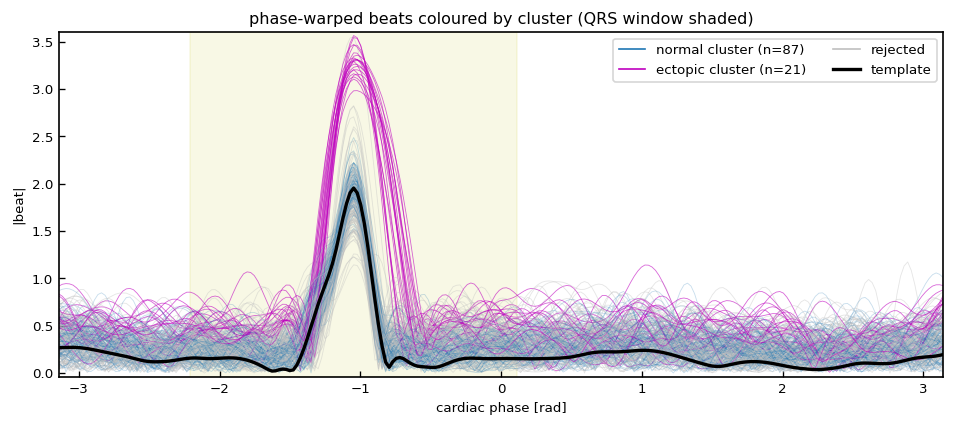

In [4]:
# normal template = largest QRS-correlation cluster
B = build_phase_template(ff, peaks, fs, corr_halfwidth_ms=QRS_HALFWIDTH_MS)
print(f"{B['n_total']} beats  ->  normal cluster of {B['n_members']} at threshold {B['threshold_used']:.2f}")

# distinct secondary mode among the rest (the ectopic beats)
ec_idx, ec_thr, _ = select_secondary_cluster(B['beats'], B['member_idx'],
                                             qrs_slice=B['qrs_slice'], min_members=5)
print(f'secondary (ectopic) cluster: {len(ec_idx)} beats at threshold {ec_thr:.2f}')

plot_clusters(B, ec_idx)

## Compare the templates with plain averaging

Both methods average the same number of beats per class (`N_PER_CLASS`). Plain averaging takes
the most-typical normals and most-distinct ectopics from the p089 classification; Oster takes the
most representative beats of each cluster above. The templates are projected to a 3-D VCG loop
through a fitted lead field. Averaging the whole ectopic class instead would dilute it toward
normal, so the naive all-beats average is shown for reference.

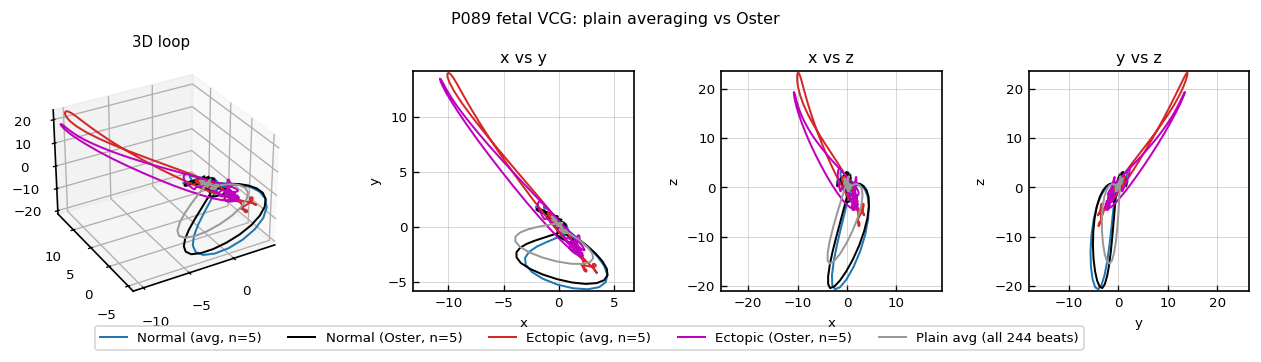

QRS angle [deg]:  normal avg-vs-Oster 4  |  ectopic avg-vs-Oster 6  |  normal-vs-ectopic 147


In [5]:
# p089 classification heuristic on fixed-window beats
Ef = extract_epochs(ff, peaks, fs, interval=1)[0]
win = np.diff(peaks).mean(); lo = ro = int(0.5 * win)
peaks_v = peaks[(peaks >= lo) & (peaks <= len(ff) - ro)]
N, Tw, _ = Ef.shape
rr = np.diff(peaks_v); premature = np.zeros(N, bool); premature[1:] = rr < 0.80 * np.median(rr)
qc, wq = Tw // 2, max(3, int(0.08 * fs))
seg = Ef[:, qc - wq:qc + wq].reshape(N, -1)
seg = seg - seg.mean(1, keepdims=True); seg /= np.linalg.norm(seg, axis=1, keepdims=True) + 1e-9
tmpl = seg[~premature].mean(0); tmpl /= np.linalg.norm(tmpl) + 1e-9
corr_norm = seg @ tmpl
c1 = np.where(premature & (corr_norm < np.median(corr_norm)))[0]   # ectopic
c0 = np.where(~premature)[0]                                       # normal

# plain averaging vs Oster, N_PER_CLASS beats each
nb_normal = Ef[c0[np.argsort(-corr_norm[c0])][:N_PER_CLASS]].mean(0)
nb_ectopic = Ef[c1[np.argsort(corr_norm[c1])][:N_PER_CLASS]].mean(0)
oster_normal = B['beats'][top_rep(B['beats'], B['member_idx'], B['qrs_slice'], N_PER_CLASS)].mean(0)
oster_ectopic = B['beats'][top_rep(B['beats'], ec_idx, B['qrs_slice'], N_PER_CLASS)].mean(0)

to_vcg = make_vcg_projector(Ef[c0].mean(0), r_sensors, valid, W_n)
loops = [
    (to_vcg(nb_normal), f'Normal (avg, n={N_PER_CLASS})', 'C0'),
    (to_vcg(oster_normal), f'Normal (Oster, n={N_PER_CLASS})', 'k'),
    (to_vcg(nb_ectopic), f'Ectopic (avg, n={N_PER_CLASS})', 'C3'),
    (to_vcg(oster_ectopic), f'Ectopic (Oster, n={N_PER_CLASS})', 'm'),
    (to_vcg(Ef.mean(0)), f'Plain avg (all {N} beats)', '0.6'),
]
plot_vcg_loops(loops, 'P089 fetal VCG: plain averaging vs Oster')

nV, oN, eV, oE = loops[0][0], loops[1][0], loops[2][0], loops[3][0]
print(f'QRS angle [deg]:  normal avg-vs-Oster {qrs_angle(nV, oN):.0f}  |  '
      f'ectopic avg-vs-Oster {qrs_angle(eV, oE):.0f}  |  normal-vs-ectopic {qrs_angle(nV, eV):.0f}')